# Config

In [1]:
'''#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
'''

'#MOana specific\nimport os, subprocess\nprint("PID:", os.getpid())\nprint("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))\nprint("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())\nprint(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)\n'

In [2]:
#MOANA ONLY
'''
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
'''

'\n#os.environ["CUDA_VISIBLE_DEVICES"] = "1"\n#check for errors\nos.environ["CUDA_LAUNCH_BLOCKING"] = "1"\n'

In [1]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [2]:
# Cell 0 — CONFIG
#case
case_name = "402_Hide_n_seek"
experiment = "v_01_temp"
asset_name = f"{case_name}_{experiment}"
import json
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

project_root: /workspace/project
/workspace/project True
/workspace/project/Data/402_Hide_n_seek/010_source
Case    : 402_Hide_n_seek
Video   : VID_20260815_165930783.mp4
video fps: 30.000
total_frames 7655


In [1]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [3]:
#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


# AI First Pass
## Gem, vid to text

In [6]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini_v02 import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")

re_caching video
Here is a detailed summary of the hide-and-seek game shown in the video, broken down by sections with timestamps:

**00:00 - 00:32**
The video begins on a paved backyard patio where a man prepares to play a game of hide-and-seek. He starts counting down from one to ten to give the other players time to hide, with the camera occasionally focusing on his arm and watch during the countdown.

**00:32 - 01:05**
After completing the countdown, the seeker begins scanning the garden. Hearing rustling noises near the trees, he walks over to a large tree trunk surrounded by bushes and finds the first hider, a woman wearing sunglasses and a black shirt, crouching in the foliage.

**01:05 - 01:37**
The seeker continues down the garden path, passing compost bins and heading toward the hedges on the far side of the lawn. He follows the sound of laughter and discovers the second hider, an older woman in a blue shirt, smiling and waving from behind a bush.

**01:37 - 02:14**
Moving ba

## Producer 1

In [76]:
Question = "Make a video summary of this video and show where each person was hiding"

In [22]:
#PRODUCER DRAFT 1
from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")

[12:14:05 +  0.00s] run_producer_agent: start
[12:14:05 +  0.00s] thread: start
[12:14:05 +  0.00s] event loop: created
[12:14:05 +  0.00s] query: start


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[12:14:12 +  7.27s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=13806 cache_read=2643
[12:14:12 +  7.27s] turn 1 content blocks: ['ThinkingBlock']
[12:14:12 +  7.27s] thinking:
I'm drafting the JSON structure now, with a brief summarizing where each person hid since geography matters more than GPS, so I'll use a BEV_MAP. The beats will cover the establishing countdown, five find beats, the map reveal, and the aftermath.
[12:14:47 + 42.07s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=13806 cache_read=2643
[12:14:47 + 42.07s] turn 2 content blocks: ['ToolUseBlock']
[12:14:47 + 42.07s] tool call: Write (/workspace/project/Data/402_Hide_n_seek/012_agent_p_output/v_01_temp/402_Hide_n_seek_paper_edit_draft.json)
[12:14:47 + 42.07s] write content:
{
  "case_name": "402_Hide_n_seek",
  "brief": "Make a video summary of this video and show where each person was hiding",
  "beats": [
    {
      "archetype": "ESTABLISHER",
      "order": 1,
      "beat_id": ["beat-01"],
      "

In [4]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path
restart = True
if restart == True:
    #2d ANALYSIS - JUST GPS now!
    from D_2d_analysis import analysis_2D
    analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
    print(analysis_2d_for_decisions)

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

{'GPS_signal': 'no'}

=== Rendered HTML ===
  /workspace/project/Data/402_Hide_n_seek/012_agent_p_output/v_01_temp/402_Hide_n_seek_draft_paper_edit.html
Paper edit flag corrections (feed back to Producer):
- Beat ['beat-03']: added TRACKING (Producer didn't request it).
- Beat ['beat-03']: added TRACKING (Producer didn't request it).
- Beat ['beat-04']: added TRACKING (Producer didn't request it).
- Beat ['beat-04']: added TRACKING (Producer didn't request it).
- Beat ['beat-05']: added TRACKING (Producer didn't request it).
- Beat ['beat-05']: added TRACKING (Producer didn't request it).
- Beat ['beat-06']: added TRACKING (Producer didn't request it).
- Beat ['beat-06']: added TRACKING (Producer didn't request it).
- Beat ['beat-07']: added TRACKING (Producer didn't request it).
- Beat ['beat-07']: added TRACKING (Producer didn't request it).
- Beat ['beat-08']: added TRACKING (Producer didn't request it).
- Beat ['beat-08']: added TRACKING (Producer didn't request it).

=== Derived f

# Tracking

In [6]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path)) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)
else:
    print("Cell disabled")

here
accessing data
here
None
None
[{'gem_person_id': 'person-1', 'descriptor': 'Woman in black t-shirt, khaki pants, and sunglasses'}, 'the large tree trunk']
[{'gem_person_id': 'person-2', 'descriptor': 'Older woman with blonde hair in a blue short-sleeved shirt'}, 'the bush']
[{'gem_person_id': 'person-3', 'descriptor': 'Man in grey t-shirt and dark shorts'}, 'the green dustpan']
[{'gem_person_id': 'person-4', 'descriptor': 'Older man in blue and white striped polo shirt'}, 'the brown wheelie bin']
[{'gem_person_id': 'person-5', 'descriptor': 'Woman with curly dark hair and dark shirt'}, 'the climbing plants']
[{'gem_person_id': 'person-6', 'descriptor': 'Young girl in green dress holding stuffed animals'}, {'gem_person_id': 'person-7', 'descriptor': 'Teenage girl on the left in white t-shirt and black shorts'}, {'gem_person_id': 'person-8', 'descriptor': 'Teenage girl on the right in white t-shirt and black shorts'}, 'the large round bush']
[{'gem_person_id': 'person-1', 'descripto

frame loading (OpenCV) [rank=0]: 100%|██████████| 365/365 [00:02<00:00, 142.50it/s]
INFO 2026-08-18 21:40:48,478 3486239 sam3_base_predictor.py: 146: started new session eafb1492-ead2-43c2-825d-c7bdf01bb945
propagate_in_video: 100%|██████████| 365/365 [01:44<00:00,  3.49it/s]
INFO 2026-08-18 21:42:33,736 3486239 sam3_base_predictor.py: 305: propagation ended in session eafb1492-ead2-43c2-825d-c7bdf01bb945
INFO 2026-08-18 21:42:34,019 3486239 sam3_base_predictor.py: 409: removed session eafb1492-ead2-43c2-825d-c7bdf01bb945


[person] requested 83-98s -> keyframe-aligned start frame 2490


frame loading (OpenCV) [rank=0]: 100%|██████████| 454/454 [00:02<00:00, 168.12it/s]
INFO 2026-08-18 21:42:48,978 3486239 sam3_base_predictor.py: 146: started new session 7c8c2bae-845d-45e2-a6b4-14824db47e44
propagate_in_video: 100%|██████████| 454/454 [01:53<00:00,  3.99it/s]
INFO 2026-08-18 21:44:43,478 3486239 sam3_base_predictor.py: 305: propagation ended in session 7c8c2bae-845d-45e2-a6b4-14824db47e44
INFO 2026-08-18 21:44:43,770 3486239 sam3_base_predictor.py: 409: removed session 7c8c2bae-845d-45e2-a6b4-14824db47e44


[person] requested 112-124s -> keyframe-aligned start frame 3360


...

[the_climbing_plants] requested 149-157s -> keyframe-aligned start frame 4470


frame loading (OpenCV) [rank=0]: 100%|██████████| 243/243 [00:01<00:00, 174.70it/s]
INFO 2026-08-18 21:58:28,276 3486239 sam3_base_predictor.py: 146: started new session bd2ab62b-d9bf-4822-ace5-5de1c877892a
propagate_in_video: 100%|██████████| 243/243 [01:33<00:00,  2.61it/s]
INFO 2026-08-18 22:00:01,797 3486239 sam3_base_predictor.py: 305: propagation ended in session bd2ab62b-d9bf-4822-ace5-5de1c877892a
INFO 2026-08-18 22:00:02,045 3486239 sam3_base_predictor.py: 409: removed session bd2ab62b-d9bf-4822-ace5-5de1c877892a


[the_large_round_bush] requested 225-247s -> keyframe-aligned start frame 6720
[local SAM3] 683 frames -> offloading video+state to CPU


frame loading (OpenCV) [rank=0]: 100%|██████████| 683/683 [00:04<00:00, 155.21it/s]
INFO 2026-08-18 22:00:21,539 3486239 sam3_base_predictor.py: 146: started new session b89f45a3-c707-4783-99a6-d391143ec909
propagate_in_video:   8%|▊         | 53/683 [00:22<04:29,  2.34it/s]
INFO 2026-08-18 22:00:44,578 3486239 sam3_base_predictor.py: 305: propagation ended in session b89f45a3-c707-4783-99a6-d391143ec909
INFO 2026-08-18 22:00:45,088 3486239 sam3_base_predictor.py: 409: removed session b89f45a3-c707-4783-99a6-d391143ec909


[the_large_round_bush] OBJECT TOO DENSE -- 'the large round bush' expected ~1, but frame 39 held 4; skipping span
[the_large_round_bush] not tracked -- every span was too dense
[local SAM3] released -- 4.72GiB still allocated
{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928

In [7]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "man")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)

In [21]:
print(masks_dir)

/workspace/project/Data/402_Hide_n_seek/015_SAM3_masks/v_01_temp


In [ ]:
#mask checker (overlays)
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, mask,  name = f"hidenseek_v1_temp_{mask.name}")
    

/workspace/project/Data/402_Hide_n_seek/015_SAM3_masks/v_01_temp


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

In [6]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


## Filter and store object tracking data in analysis 2D

In [31]:
#Analysis 2D
from D_2d_analysis import analysis_2d_from_masks, analysis_2d_gemvsSAM
from render_paper_edit import paper_edit_path
from pprint import pprint

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

#noun phrases form paper edit vs masks
analysis_2d_for_decisions.update(analysis_2d_from_masks(paper_edit_json_path))  # non-person subjects, from mask folders
#Gemini people from paper edit  VS sam csv
#analysis_2d_for_decisions.update(analysis_2d_gemvsSAM())                        # gem_person_id entries, from detections.csv
pprint(analysis_2d_for_decisions)

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'GPS_signal': 'no',
 'the_brown_wheelie_bin-01': {'Subject_frames_present': [3853,
                                                         3854,
                                                         3855,
                                                         3856,
                                                         3857,
                                                         3858,
                                                         3859,
                                                         3860,
                                                         3861,
                                                         3862,
                                                         3863,
                                                         3864,
                                                         3865,
                                                         3866,
                                                         3867,
                                  

## Match SAM3 and GOOGLE people in Analysis 2D

In [97]:
#MATCHING
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(crops_by_track=crops, fps=fps)

analysis_2d_for_decisions.update(analysis_2d_gemvsSAM(
    gem_person_targets=gem_person_targets_lookup(fps),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
))

[person-01] 10 crop(s) from 145 masked frames
[person-02] 10 crop(s) from 33 masked frames
[person-03] 10 crop(s) from 49 masked frames
[person-04] 10 crop(s) from 153 masked frames
[person-05] 9 crop(s) from 9 masked frames
[person-06] 10 crop(s) from 45 masked frames
[person-07] 10 crop(s) from 251 masked frames
[person-08] 7 crop(s) from 7 masked frames
[person-09] 10 crop(s) from 137 masked frames
[person-10] 10 crop(s) from 99 masked frames
[person-11] 3 crop(s) from 3 masked frames
[person-12] 10 crop(s) from 82 masked frames
[person-13] 9 crop(s) from 9 masked frames
[person-14] 10 crop(s) from 25 masked frames
[person-15] 10 crop(s) from 24 masked frames
[person-16] 4 crop(s) from 4 masked frames
[person-17] 10 crop(s) from 55 masked frames
[person-18] 10 crop(s) from 43 masked frames
[person-19] 10 crop(s) from 36 masked frames
[person-20] 10 crop(s) from 39 masked frames
[person-21] 10 crop(s) from 133 masked frames
[person-22] 10 crop(s) from 70 masked frames
[person-23] 10 

# RECON
## Frame Selection

In [6]:
#FRAME SELECTION POSES - Frame selection to make the cam poses
if flags["RECON_CAM_POSES"] == True and flags["FRAME_SELECTION"] == True:
    from render_paper_edit import recon_window_frames
    start_cam_recon , end_cam_recon = recon_window_frames(paper_edit_json_path=None, fps=None, flag="RECON_CAM_POSES")
    capacity = 200
    recon_dur = end_cam_recon - start_cam_recon
    cam_recon_interframe_interval =   (recon_dur+capacity-1) // capacity
    print("interval" , cam_recon_interframe_interval)

    # Parameters
    fps = fps
    interval     = cam_recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = fps/2     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        video_path = str(video_path),
        output_dir    = str(frames_for_cam_poses),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_cam_recon,
        end_frame    = end_cam_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

RECON_CAM_POSES: 32-232s @ 30.0fps
interval 30
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 960-6960 (6000 frames)
Sampling: every 30 frames (1.0s) → 200 candidates
Window  : ±15 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 6000/6000 [00:34<00:00, 175.13fr/s]


Selected: 200 frames  (128 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 6000/6000 [00:19<00:00, 313.08fr/s]

Log     : /workspace/project/Data/402_Hide_n_seek/020_frames_for_cam_poses/v_01_temp/selection_log.json
Sharpness (at 25% res): min 178 · mean 4715 · max 18948

2 frames written to /workspace/project/Data/402_Hide_n_seek/020_frames_for_recon/v_01_temp


In [11]:
print(flags)

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION_MAP': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': True, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


In [12]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon
if flags["RECON_3D"] == True :
    from render_paper_edit import recon_window_frames
    start_3D_recon , end_3D_recon = recon_window_frames(paper_edit_json_path=None, fps=None, flag="RECON_3D")
    capacity = 200
    recon_dur = end_3D_recon - start_3D_recon
    cam_recon_interframe_interval =   (recon_dur+capacity-1) // capacity
    print("interval" , cam_recon_interframe_interval)

    # Parameters
    fps = fps
    interval     = cam_recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = fps/2     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_recon),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon, 
        end_frame    = end_3D_recon 

    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

Cell disabled


## VGGT OMEGA

In [8]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [14]:
print(torch.cuda.memory_allocated()/2**30, torch.cuda.memory_reserved()/2**30)


0.0 0.0


In [7]:
#VGGT OMEGA 
#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

from A_Config import recon_for_MAP_dir, recon_for_EVENT_dir

recon_jobs = []
if flags['RECON_CAM_POSES']:
    recon_jobs.append((frames_for_cam_poses, recon_for_MAP_dir()))
if flags['RECON_3D']:
    recon_jobs.append((frames_for_recon, recon_for_EVENT_dir()))

for frames, recon_out in recon_jobs:
    run_vggt_omega(image_dir=str(frames), 
               output_dir=recon_out,checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"), 
vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
image_resolution=512, conf_thres=20.0, max_points=0, show_cam=True, )

199 frames  →  /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01_temp
Saved: /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01_temp/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01_temp/scene.glb


# POST RECON
## Processing

In [8]:
#LOAD VGGT_O recon for further processing
from Thr3D.F_post_recon_processing import Reconstruction
def PRP(recon,frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    from Thr3D.F_post_recon_processing import positions_to_frame_dict
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

if flags['RECON_CAM_POSES']:
    recon_MAP = Reconstruction.load(frames_for_cam_poses, recon_for_MAP_dir() / "predictions.npz", FRAME_NAME_FMT)
    MAP_poses_dict = PRP(recon_MAP, frames_for_cam_poses)

if flags['RECON_3D']:
    recon_EVENT = Reconstruction.load(frames_for_recon, recon_for_MAP_dir()/ "predictions.npz", FRAME_NAME_FMT)
    EVENT_poses_dict = PRP(recon_EVENT, frames_for_recon)

In [9]:
#TRANSFORM CAMERA POSES VS GPS
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions['GPS_signal']== 'yes':
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, MAP_poses_dict)
else:
    print("Cell disabled")

Cell disabled


## Recon Visualisation

In [10]:
#Convert into model space and export into plys
if flags['RECON_CAM_POSES']:
    #Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
    ext = recon_MAP.preds["extrinsic"][0].clone()
    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 

    _ = recon_MAP.VGGT_O_preds_to_ply_export(VGGT_O_output_dir /"MAP" / "ply" , 
                                            R=ext[:,0:3], 
                                            t=ext[:,3], 
                                            s=1)
if flags['RECON_3D']:
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
    ext = recon_EVENT.preds["extrinsic"][0].clone()
    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
    _ = recon_MAP.VGGT_O_preds_to_ply_export(VGGT_O_output_dir /"EVENT" / "ply" , 
                                            R=ext[:,0:3], 
                                            t=ext[:,3], 
                                            s=1)

In [11]:
# Cell — PLY visualisation
if  flags["RECON_3D"] == True:     
    import importlib
    import F_cut3r_vis; importlib.reload(F_cut3r_vis)
    from F_cut3r_vis import visualise_cut3r
    visualisation_dir =   VGGT_O_output_dir /"EVENT" 
    visualise_cut3r(visualisation_dir)

else:
    print("cell disabled")

if  flags["RECON_CAM_POSES"] == True:     
    import importlib
    import F_cut3r_vis; importlib.reload(F_cut3r_vis)
    from F_cut3r_vis import visualise_cut3r
    visualisation_dir =   VGGT_O_output_dir /"MAP" 
    print(visualisation_dir)
    visualise_cut3r(visualisation_dir)

else:
    print("cell disabled")

cell disabled
/workspace/project/Data/402_Hide_n_seek/035_VGGT_O_output/v_01_temp/MAP
Found 336 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

In [12]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   

## ANALYSIS 3D

In [98]:
#depth confidence statistics
if flags["RECON_CAM_POSES"] == True: 
    recon = recon_MAP
conf     = recon.preds["depth_conf"].cpu().numpy()
print("min, max confidence",conf.min(), conf.max())
print("frames, y, x",conf.shape)
print("confidence percentiles", np.percentile(conf, [5,10, 25, 50, 75, 95]))

from C_CSV_report import add_to_report
report_items = {
    "Depth Confidence (min)"      : conf.min(), 
    "Depth Confidence (max)"      : conf.max(),
    "Depth Confidence (mean)"     : conf.mean(),
    "Depth COnfidence percentiles" : np.percentile(conf, [5, 25, 50, 75, 95])
}
add_to_report(report_items)

min, max confidence 1.0000002 30.980795
frames, y, x (199, 384, 688)
confidence percentiles [ 1.07193208  1.5130077   2.8234148   4.5650177   6.59387589 12.24139876]


## no gps

In [99]:
#multi subject positioning - NO GPS
if analysis_2d_for_decisions['GPS_signal'] == "no":
    from Q_subject_analysis import find_mask_centroids_in_model_space
    from pathlib import Path
    cv2.setLogLevel(0)
    
    subjects_positions_multi_dict = {}
    subjects_depth_std_multi_dict = {}
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        print(F"3D analysis of {subject_slug}")
        merged_SAMS = {}
        merged_std  = {}
        for track_dir in track_dirs:
            track_dir = Path(track_dir)
            centroids, frame_keys, depth_std_model = find_mask_centroids_in_model_space(
                recon, masks_dir = track_dir, RA=1, analyse=False
            )
            print(centroids)
            for fk, c, s in zip(frame_keys, centroids, depth_std_model):
                if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                    merged_SAMS[fk] = c
                    merged_std[fk]  = s
        subjects_positions_multi_dict[subject_slug]  = merged_SAMS
        subjects_depth_std_multi_dict[subject_slug]  = merged_std
        print(F"3D analysis of {subject_slug} completed")

3D analysis of the_large_tree_trunk-01


/workspace/project/src/Q_subject_analysis.py:288: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:292: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:296: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R


nan


/workspace/project/src/Q_subject_analysis.py:309: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


[[        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [ 0.74376095  0.06798781 -0.81446905]
 [ 0.73519113  0.09238952 -0.81332498]
 [ 0.73263476  0.1061483 

In [100]:
for k, v in analysis_2d_for_decisions.items():
    print(f"{k}: {v}")



GPS_signal: no
the_large_tree_trunk-01: {'Subject_frames_present': [1623, 1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681, 1682, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 1690, 1691, 1692, 1693, 1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1719, 1720, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 18

In [101]:
for k, v in subjects_positions_multi_dict.items():
    print(f"{k}: {v}")

print(subjects_positions_multi_dict)

the_large_tree_trunk-01: {1657: array([ 0.74376095,  0.06798781, -0.81446905]), 1680: array([ 0.73519113,  0.09238952, -0.81332498]), 1705: array([ 0.73263476,  0.1061483 , -0.80510095]), 1830: array([ 0.70414883,  0.11106151, -0.84606055]), 1869: array([ 0.71825802,  0.0953778 , -0.82541712]), 1890: array([ 0.72913312,  0.08889174, -0.82744519]), 1920: array([ 0.72526339,  0.10563829, -0.83407844]), 1937: array([ 0.71897319,  0.10409907, -0.83362279])}
the_large_tree_trunk-02: {1729: array([ 0.54341855,  0.24925265, -0.97063218])}
the_large_tree_trunk-03: {1729: array([ 0.57210651,  0.24948847, -0.95761154])}
the_green_dustpan-01: {3430: array([-0.6821662 , -0.02116806,  0.1463914 ]), 3450: array([-0.67794417, -0.02250251,  0.14782404]), 3480: array([-0.68022193, -0.02288134,  0.14826563]), 3665: array([-0.71717426,  0.00272846,  0.14547959]), 3677: array([-0.72384721,  0.00637891,  0.14905479])}
the_brown_wheelie_bin-01: {3873: array([-0.5545403 ,  0.16551449, -0.67809553]), 3930: ar

## get the stats done
positions
speed 
direction

In [102]:
#DELETE ONCE THE BELOW CELL IS PROVEN TO WORK
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
MULTI_PART_RECON = False
if flags["RECON_CAM_POSES"] == True and flags["RECON_3D"] ==True:
    if MULTI_PART_RECON == False:
        from Q_subject_analysis import subject_to_metric_and_gps_space
        from Thr3D.G_transforms_alignments import  recon_to_recon_transform
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

        sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
            recon,
            masks_dir        = str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
            )    

        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
        _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
        print(VGGT_O_output_dir / "predictions.npz")
    else:
        print("Cell disabled")
else:
     print("Cell disabled")

Cell disabled


## MERGE INTO NON GPS

In [103]:
#METRIC and LAT LON processes spatial information about the recon and the subjects - for report and to map the subject
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions["GPS_signal"] == "yes" :
    from Q_subject_analysis import subject_to_metric_and_gps_space
    from Thr3D.G_transforms_alignments import  recon_to_recon_transform
    from pathlib import Path
    R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

    subjects_real_pos_multi_dict = {}
    subjects_latlon_multi_dict   = {}
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        merged_real   = {}
        merged_latlon = []
        for track_dir in track_dirs:
            sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
                recon,
                masks_dir        = str(Path(track_dir)),
                lat_0=lat_0, lon_0=lon_0,
                R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
                )
            for fk, p in sub_pos_real_dict.items():
                if np.isfinite(np.asarray(p)).all():
                    merged_real[fk] = p
            merged_latlon += list(sub_latlon)
        subjects_real_pos_multi_dict[subject_slug] = merged_real
        subjects_latlon_multi_dict[subject_slug]   = sorted(merged_latlon)

    #TEMP! keep the old single-subject names alive for the cells below - first subject
    sub_pos_real_dict = next(iter(subjects_real_pos_multi_dict.values()), {})
    sub_latlon        = next(iter(subjects_latlon_multi_dict.values()), [])
    sub_pos           = np.array([sub_pos_real_dict[f] for f in sorted(sub_pos_real_dict)])

    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
    _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
    
    print(VGGT_O_output_dir / "predictions.npz")
   
else:
     print("Cell disabled")

Cell disabled


In [104]:
for k, v in subjects_positions_multi_dict.items():
    print(f"{k}: {v}")



the_large_tree_trunk-01: {1657: array([ 0.74376095,  0.06798781, -0.81446905]), 1680: array([ 0.73519113,  0.09238952, -0.81332498]), 1705: array([ 0.73263476,  0.1061483 , -0.80510095]), 1830: array([ 0.70414883,  0.11106151, -0.84606055]), 1869: array([ 0.71825802,  0.0953778 , -0.82541712]), 1890: array([ 0.72913312,  0.08889174, -0.82744519]), 1920: array([ 0.72526339,  0.10563829, -0.83407844]), 1937: array([ 0.71897319,  0.10409907, -0.83362279])}
the_large_tree_trunk-02: {1729: array([ 0.54341855,  0.24925265, -0.97063218])}
the_large_tree_trunk-03: {1729: array([ 0.57210651,  0.24948847, -0.95761154])}
the_green_dustpan-01: {3430: array([-0.6821662 , -0.02116806,  0.1463914 ]), 3450: array([-0.67794417, -0.02250251,  0.14782404]), 3480: array([-0.68022193, -0.02288134,  0.14826563]), 3665: array([-0.71717426,  0.00272846,  0.14547959]), 3677: array([-0.72384721,  0.00637891,  0.14905479])}
the_brown_wheelie_bin-01: {3873: array([-0.5545403 ,  0.16551449, -0.67809553]), 3930: ar

In [105]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions["GPS_signal"] == "yes" :
    from matplotlib import pyplot as plt
    from matplotlib.lines import Line2D

    subj    = subjects_real_pos_multi_dict if "subjects_real_pos_multi_dict" in dir() else subjects_positions_multi_dict
    markers = ["o", "^", "s", "D", "v", "P"]
    print(subj)
    fig, ax = plt.subplots()
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
    handles = []
    for (slug, d), mk in zip(subj.items(), markers):
        frames = np.array(sorted(d))
        pts    = np.array([d[k] for k in frames])
        sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                        vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
        handles.append(Line2D([0], [0], marker=mk, ls="", color="white", label=slug))

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("frame", color="white")
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    ax.legend(handles=handles, labelcolor="white", facecolor="black", edgecolor="white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.set_xlabel("x")
    ax.set_ylabel("z)")
    ax.set_title("Subject position (color = time)")

In [106]:
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions["GPS_signal"] == "yes" :
      print(subjects_positions_multi_dict.keys()
            )

      print(subjects_positions_multi_dict['person-02']      )

{}


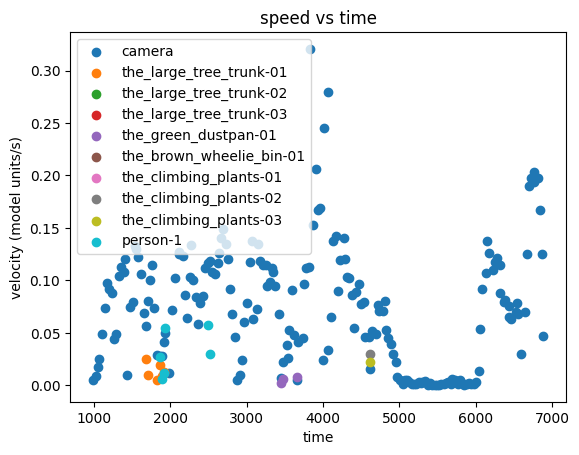

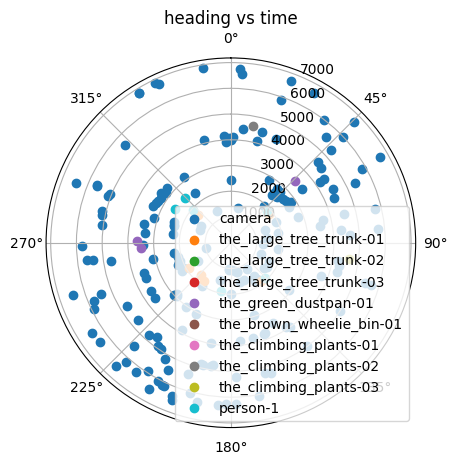

In [107]:
##3D Graphing and analysis METRIC OR NOT
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests
from A_Config import has_gps_data
fps = fps
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
if flags['RECON_CAM_POSES']:
    cam_poses_model_dict = MAP_poses_dict
group_metrics = speed_direction({"camera": cam_poses_model_dict, **subjects_positions_multi_dict}, fps)

lat, lon = (lat_0, lon_0) if has_gps_data() else (None, None)

meetings = {}
for A_dict_entry, B_dict_entry in build_meeting_requests():   # [["person-1","person-2"], ["person-1","camera"]]
    B_is_camera = B_dict_entry == "camera"
    A_real_dict = subjects_positions_multi_dict[A_dict_entry]
    B_real_dict = cam_poses_model_dict if B_is_camera else subjects_positions_multi_dict[B_dict_entry]

    meetings[(A_dict_entry, B_dict_entry)] = meeting_calculator(
        A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
        lat_0=lat, lon_0=lon, B_is_camera=B_is_camera)

print(meetings)

##TEMP TESTS

In [108]:
print(analysis_2d_for_decisions.keys())


dict_keys(['GPS_signal', 'the_large_tree_trunk-01', 'the_large_tree_trunk-02', 'the_large_tree_trunk-03', 'the_green_dustpan-01', 'the_brown_wheelie_bin-01', 'the_climbing_plants-01', 'the_climbing_plants-02', 'the_climbing_plants-03', 'person-1', 'person-2', 'person-3', 'person-4', 'person-5', 'person-6', 'person-7', 'person-8'])


## this will be deleted

In [109]:
#depth based intersections checker # TEMP
#mask overlay sequence: person-1 (green) vs sword (magenta)
interceptions = False
if interceptions ==  True:
    from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
    from A_Config import assets_dir, source_video_path
    from pathlib import Path
    import cv2
    A_slug, B_slug = "person-1", "the_large_sword-1"
    def _dirs(slug):
        e = analysis_2d_for_decisions[slug]
        return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
    A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
    #sword is person 5
    B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



    out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                    set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

    cap = cv2.VideoCapture(str(source_video_path()))
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            continue
        for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
            m = _load_mask_bool(d, f)
            if m is not None:
                frame = apply_mask_overlay(frame, m, color=colour)
        cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
    cap.release()
    print(out_dir, len(frames), "frames")

# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [110]:
# subject touching test
interceptions = False
if interceptions ==  True:
    from Q_subject_analysis import contact_frames
    res = contact_frames(recon, A_dir, B_dir)

    r = res[386]          # your contact frame
    plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
    plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
    plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
    print(r["depth_gap"], r["fit_resid"], r["contact"])

# Rendering
## Point_cloud based

In [111]:
#projection map
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from Thr3D.F_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from Two2D.B_video_processing import available_frames
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)
    if MULTI_PART_RECON == True:
      recon = recons
      
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        main_idx      = 3908,
        extra_indices = extra_indices,
        #extra_indices = range (3854,4397),
        #other syntax  [400,4027, 4052, 4065],
        #extra_indices = [extra_indices], - for composite (double [[]])
        masks_dir     = str(yolo_masks_dir),

        new_view = ext ,
        
        confidence_threshold = 2
       
       )
else:
    print("Cell disabled")

Cell disabled


# PRODUCER 2

In [112]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'the_large_tree_trunk-01': {'Subject_frames_present': [1623, 1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681, 1682, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 1690, 1691, 1692, 1693, 1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1719, 1720, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 

In [113]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

PosixPath('/workspace/project/Data/402_Hide_n_seek/012_agent_p_output/v_01_temp/402_Hide_n_seek_paper_edit_draft.json')

In [114]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)

[14:11:31 +  0.00s] run_producer_agent: start
[14:11:31 +  0.00s] thread: start
[14:11:31 +  0.00s] event loop: created
[14:11:31 +  0.00s] query: start
[14:13:02 + 91.03s] turn 1 usage (claude-sonnet-5): in=2 out=5 cache_write=33257 cache_read=0
[14:13:02 + 91.03s] turn 1 content blocks: ['ThinkingBlock']
[14:13:02 + 91.03s] thinking:
I'm checking the draft against the feasibility flags for this case—only BEV_MAP is true, while tracking, recon, Google Map, projection map, mask overlays, and multicam are all false, so I need to make sure the draft only references what's actually available.

BEV_MAP being True while RECON_3D, RECON_CAM_POSES, and TRACKING are all False is contradictory, since BEV_MAP needs one of those to place subject positions - so it can only be a static map without a tracked path. I'm treating MASK_OVERLAYS as infeasible across all beats and need to figure out how to handle the mandatory MAP requirement in beat-09 given this conflict, since R5.1 says MAP must always

## Mapping

In [115]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Cell disabled


In [116]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)

In [117]:
#BEV SETUP
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames
#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_cam_poses, FRAME_NAME_FMT)

In [118]:
print("confidence percentiles", np.percentile(conf, [5,10, 25, 50, 75, 95]))

confidence percentiles [ 1.07193208  1.5130077   2.8234148   4.5650177   6.59387589 12.24139876]


In [119]:
#BEV HI RES
#BEV projection mapping of subject to a selected view
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params, BEV_path = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=np.percentile(conf, 60) ,
                   margin_frac=0.05)  

[975, 984, 1030, 1050, 1067, 1110, 1149, 1168, 1200, 1234, 1260, 1290, 1328, 1350, 1395, 1414, 1437, 1468, 1515, 1543, 1557, 1580, 1616, 1657, 1680, 1705, 1729, 1760, 1785, 1830, 1869, 1890, 1920, 1937, 1981, 2025, 2067, 2112, 2117, 2162, 2194, 2220, 2256, 2269, 2297, 2337, 2360, 2385, 2428, 2460, 2501, 2520, 2550, 2585, 2621, 2640, 2670, 2697, 2726, 2760, 2779, 2806, 2850, 2872, 2910, 2940, 2961, 3008, 3045, 3075, 3082, 3135, 3150, 3173, 3210, 3251, 3270, 3300, 3330, 3348, 3376, 3430, 3450, 3480, 3525, 3538, 3555, 3592, 3619, 3665, 3677, 3735, 3757, 3780, 3810, 3830, 3873, 3910, 3930, 3958, 4000, 4011, 4065, 4071, 4098, 4127, 4167, 4191, 4220, 4275, 4290, 4320, 4346, 4380, 4410, 4427, 4473, 4493, 4530, 4552, 4598, 4620, 4639, 4692, 4714, 4726, 4784, 4808, 4830, 4848, 4885, 4914, 4950, 4967, 5010, 5040, 5070, 5100, 5123, 5160, 5190, 5220, 5250, 5280, 5298, 5340, 5370, 5400, 5430, 5460, 5490, 5520, 5550, 5580, 5610, 5640, 5670, 5686, 5730, 5760, 5790, 5805, 5850, 5880, 5910, 5930, 5970,

In [120]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes BEV from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=subjects_positions_multi_dict,
    bev_png_path = BEV_path
)

Skipping subject trace 'the_large_tree_trunk-02' -- only 1 frame(s) overlap extra_indices.
Skipping subject trace 'the_large_tree_trunk-03' -- only 1 frame(s) overlap extra_indices.
Skipping subject trace 'person-6' -- only 0 frame(s) overlap extra_indices.
Skipping subject trace 'person-7' -- only 0 frame(s) overlap extra_indices.
frame 0000 t_frac=0.0000 [camera] virtual_frame=975.0 pos_px=(493.0, 370.0)
frame 0000 t_frac=0.0000 [the_large_tree_trunk-01] virtual_frame=975.0 pos_px=(816.1, 723.9)
frame 0000 t_frac=0.0000 [the_green_dustpan-01] virtual_frame=975.0 pos_px=(196.6, 306.4)
frame 0000 t_frac=0.0000 [the_brown_wheelie_bin-01] virtual_frame=975.0 pos_px=(252.0, 664.6)
frame 0000 t_frac=0.0000 [the_climbing_plants-01] virtual_frame=975.0 pos_px=(655.4, 112.5)
frame 0000 t_frac=0.0000 [the_climbing_plants-02] virtual_frame=975.0 pos_px=(695.7, 17.2)
frame 0000 t_frac=0.0000 [the_climbing_plants-03] virtual_frame=975.0 pos_px=(650.1, 89.3)
frame 0000 t_frac=0.0000 [person-1] vir

PosixPath('/workspace/project/Data/402_Hide_n_seek/090_assets/bev_trace_frames')

In [121]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

[out#0/matroska @ 0x56013dc7c540] video:205421KiB audio:2250KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.004506%
frame=  361 fps= 81 q=-0.0 Lsize=  207680KiB time=00:00:12.00 bitrate=141776.3kbits/s speed=2.71x    
ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --e

making overlay for beat beat-03


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-04


...

making overlay for beat beat-07


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-08


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

PosixPath('/workspace/project/Data/402_Hide_n_seek/090_assets/402_Hide_n_seek_v_01_temp_rough_cut.mp4')

In [122]:
from V_text_summary import gemini_final_report, gemini_cache_video
vid_path = assets_dir() / f"{asset_name}_rough_cut.mp4"
cache =  gemini_cache_video(vid_path, assets_dir(), ttl="6000s")
gemini_final_report()

On August 15, 2026, at 16:59:30, a game of hide-and-seek was filmed in a residential backyard, focusing on a man who attempted to hide by holding a green dustpan over his face. 

The man stood near a wooden fence gate while holding the green dustpan as a mask to cover his face. The seeker approached him, playfully noting that "there's no human here" before touching his shoulder, which caused the man to lower the green dustpan and laugh as he was discovered.

The man moved a net distance of 0.70 model units at a heading of 83 degrees during the recording. His involvement in the game and subsequent presence in the garden lasted from 17:01:24 to 17:03:16.
**00:00** [Seeker]: Okay, we're going to play hide and seek for the second time.

**00:08** [Seeker]: Ready? Here we go. One minute already wasted. Sorry, everybody.

**00:13** [Seeker]: Just exact... One, two, three, four, five, six, seven, eight, nine, ten. Ready or not, here I come.

**00:32** [Seeker]: I hear a rustling in the bushes

In [123]:
timer_end()

NameError: name 'timer_end' is not defined

In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))